# 다변량 LSTM 전력 수요 예측 — 학습 구간 시나리오 비교

전력·생산·기상 등 13개 변수의 **직전 24시간**을 입력으로 다음 1시간 전력(`평균`, kW)을 예측하는 다변량 LSTM이다.
학습 기간을 어떻게 나누는 것이 좋은지 4가지 시나리오로 비교하고, 최종 선택한 **시나리오 D**(1~9월 전체 학습)의 성능을 여러 관점에서 분석한다.

- **입력**: `okm_augumented_2021_processed.xlsx`
- **모델**: `LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(16) → Dense(1)`
- **평가 지표**: RMSE · MAE · MAPE · R², 과대/과소예측 비율, 급증 탐지 Precision/Recall/F1

> 같은 함수·설정을 `LSTM_AIModel.py` 모듈로도 제공한다 (다른 노트북에서 import 해서 사용).

## 0. 라이브러리 임포트 · 한글 폰트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (
2026-09-30 10:39:52.667981: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-30 10:39:52.692391: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-30 10:39:52.699076: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] U

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# 한글 폰트 설정 (OS별)
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 불러오기

In [3]:
file_path = 'okm_augumented_2021_processed.xlsx'
df = pd.read_excel(file_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
df = df.interpolate(method='linear').dropna()
print(df.columns.tolist())

['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비', '시간복원', 'datetime', '전력 구간합계', '전력 최대값', '전력 최소값', '전력 변동폭']


## 2. 입력 변수 · 시퀀스 생성 함수
- 입력 변수 13개: `평균, 생산량, 기온, 풍속, 습도, 강수량, 전기요금(계절), 공장인원, 시간, 전력 구간합계, 전력 최대값, 전력 최소값, 전력 변동폭`
- 예측 대상: `평균` (다음 1시간)

In [4]:
# 1~9월 데이터
df_1_9 = df[(df['datetime'].dt.month >= 1) & (df['datetime'].dt.month <= 9)].copy()

# 입력 변수 / 예측 대상 / 입력 시퀀스 길이(시간)
features = ['평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', '공장인원', '시간','전력 구간합계', '전력 최대값', '전력 최소값', '전력 변동폭']
target = '평균'
window_size = 24

# 직전 window_size 시간 → 다음 1시간 target
def make_sequences(data, target_idx, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size, target_idx])
    return np.array(X), np.array(y)

## 3. 모델 학습 · 평가 함수

In [5]:
# LSTM(64) → LSTM(32) → Dense(16) → Dense(1), EarlyStopping(patience=10)
def train_lstm_model(X_train, y_train, input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )
    return model

In [6]:
def evaluate_model(model, X_test, y_test, scaler, target_idx, features):
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 역스케일링: target 열에만 값을 넣은 더미 배열로 inverse_transform
    dummy_array = np.zeros((len(y_pred_scaled), len(features) + 1))
    dummy_array[:, target_idx] = y_pred_scaled.flatten()
    y_pred = scaler.inverse_transform(dummy_array)[:, target_idx]
    
    dummy_test_y = np.zeros((len(y_test), len(features) + 1))
    dummy_test_y[:, target_idx] = y_test.flatten()
    y_true = scaler.inverse_transform(dummy_test_y)[:, target_idx]
    
    # 평가 지표
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE(%)': mape, 'R2': r2}, y_true, y_pred

## 4. 학습 구간 시나리오 정의

| 시나리오 | 구간 분할 | 설명 |
|---|---|---|
| A | 1~4월 / 5~9월 | 2개 구간에 각각 모델 학습 |
| B | 1~3월 / 4~6월 / 7~9월 | 3개 구간 |
| C | 1~2월 / 3~4월 / 5~6월 / 7~9월 | 4개 구간 |
| D | 1~9월 | 전체 기간 하나의 모델 |

각 구간 안에서 시간 순서대로 학습/테스트를 나눈다.

In [7]:
scenarios = {
    "시나리오 A: 2개 구간 (1~4월 / 5~9월)": [
        ("1~4월", df_1_9['datetime'].dt.month <= 4),
        ("5~9월", df_1_9['datetime'].dt.month >= 5)
    ],
    "시나리오 B: 3개 구간 (1~3월 / 4~6월 / 7~9월)": [
        ("1~3월", df_1_9['datetime'].dt.month <= 3),
        ("4~6월", (df_1_9['datetime'].dt.month >= 4) & (df_1_9['datetime'].dt.month <= 6)),
        ("7~9월", df_1_9['datetime'].dt.month >= 7)
    ],
    "시나리오 C: 3개 구간 (1~2월 / 3~4월 /5~6월/ 7~9월)": [
        ("1~2월", df_1_9['datetime'].dt.month <= 2),
        ("3~4월", (df_1_9['datetime'].dt.month >= 3) & (df_1_9['datetime'].dt.month <= 4)),
        ("5~6월", (df_1_9['datetime'].dt.month >= 5) & (df_1_9['datetime'].dt.month <= 6)),
        ("7~9월", df_1_9['datetime'].dt.month >= 7)
    ],
    "시나리오 D: 1개 구간 ": [
        ("1~9월", df_1_9['datetime'].dt.month <= 9)
    ]
}

## 5. 시나리오별 성능 비교

### 5-1. 시나리오 B · C는 구간 앞쪽 20%를 테스트로 사용 (실험)
- 시나리오 B · C: 앞 20% = 테스트, 뒤 80% = 학습
- 나머지 시나리오: 앞 80% = 학습, 뒤 20% = 테스트

> ⚠️ 조건문이 `scenario_name in ["시나리오 B", "시나리오 C"]`로 **시나리오 이름 전체와 비교**하기 때문에, 현재 코드에서는 이 분기가 실행되지 않고 모든 시나리오가 80:20으로 분할된다.

In [8]:
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 경고 메시지 숨김
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

all_detailed_results = []

for scenario_name, periods in scenarios.items():
    print(f"\n==================================================")
    print(f" 실험 시작: {scenario_name}")
    print(f"==================================================")
    
    for period_name, condition in periods:
        sub_df = df_1_9[condition].copy()
        
        if len(sub_df) <= window_size:
            print(f"[{period_name}] 데이터 부족으로 건너뜁니다.")
            continue
            
        data_values = sub_df[features + [target]].values
        target_idx = len(features)
        
        # =====================================================================
        # [데이터 분할]
        # - 시나리오 B, C: 앞 20%를 Test, 뒤 80%를 Train으로 분할
        # - 나머지 시나리오: 앞 80%를 Train, 뒤 20%를 Test로 분할
        # =====================================================================
        if scenario_name in ["시나리오 B", "시나리오 C"]:
            test_size = int(len(data_values) * 0.2)
            # 시퀀스 생성을 위해 window_size 만큼 여유 구간 포함
            start_idx = max(0, test_size - window_size)
            test_data = data_values[start_idx : test_size + window_size]
            train_data = data_values[test_size:]
        else:
            train_size = int(len(data_values) * 0.8)
            train_data = data_values[:train_size]
            test_data = data_values[train_size - window_size:]
        
        # 스케일링
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_data)
        test_scaled = scaler.transform(test_data)
        
        # 시퀀스 생성
        X_train, y_train = make_sequences(train_scaled, target_idx, window_size)
        X_test, y_test = make_sequences(test_scaled, target_idx, window_size)
        
        print(f"학습 시퀀스: {X_train.shape}, 검증 시퀀스: {X_test.shape}")
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"[{period_name}] 시퀀스 생성 실패로 건너뜁니다.")
            continue
            
        # 모델 학습
        model = train_lstm_model(X_train, y_train, (X_train.shape[1], X_train.shape[2]))
        
        # 모델 평가
        metrics, y_true, y_pred = evaluate_model(
            model, X_test, y_test, scaler, target_idx, features
        )

        # 과대예측(예측 > 실제) / 과소예측(예측 < 실제) 분석
        over_mask = y_pred > y_true
        under_mask = y_pred < y_true

        over_count = np.sum(over_mask)
        under_count = np.sum(under_mask)

        over_rate = over_count / len(y_true) * 100 if len(y_true) > 0 else 0
        under_rate = under_count / len(y_true) * 100 if len(y_true) > 0 else 0

        over_mae = (
            np.mean(np.abs(y_true[over_mask] - y_pred[over_mask]))
            if over_count > 0 else 0
        )

        under_mae = (
            np.mean(np.abs(y_true[under_mask] - y_pred[under_mask]))
            if under_count > 0 else 0
        )

        # 결과 저장
        all_detailed_results.append({
            '시나리오': scenario_name,
            '대상 구간': period_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE(%)': metrics['MAPE(%)'],
            'R2': metrics['R2'],
            '과대예측 건수': over_count,
            '과대예측 비율(%)': over_rate,
            '과대예측 MAE': over_mae,
            '과소예측 건수': under_count,
            '과소예측 비율(%)': under_rate,
            '과소예측 MAE': under_mae
        })

        print(
            f"  - [{period_name}] 완료 | "
            f"RMSE: {metrics['RMSE']:.4f}, "
            f"MAE: {metrics['MAE']:.4f}, "
            f"MAPE: {metrics['MAPE(%)']:.2f}%, "
            f"R2: {metrics['R2']:.4f}"
        )
        print(
            f"    과대예측: {over_count}건 ({over_rate:.2f}%), "
            f"평균 절대오차: {over_mae:.4f}"
        )
        print(
            f"    과소예측: {under_count}건 ({under_rate:.2f}%), "
            f"평균 절대오차: {under_mae:.4f}"
        )
        
detailed_results_df = pd.DataFrame(all_detailed_results)
print("\n==================== [시나리오별 통합 성능 요약] ====================")
scenario_summary = detailed_results_df.groupby('시나리오')[['RMSE', 'MAE', 'MAPE(%)', 'R2']].mean().reset_index()
display(scenario_summary.round(4))


 실험 시작: 시나리오 A: 2개 구간 (1~4월 / 5~9월)
학습 시퀀스: (2280, 24, 14), 검증 시퀀스: (576, 24, 14)


I0000 00:00:1790732396.285240     524 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1790732396.349879     524 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1790732396.350225     524 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1790732396.352787     524 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

  - [1~4월] 완료 | RMSE: 15.2539, MAE: 10.0998, MAPE: 16.19%, R2: 0.9129
    과대예측: 336건 (58.33%), 평균 절대오차: 11.0181
    과소예측: 240건 (41.67%), 평균 절대오차: 8.8141
학습 시퀀스: (2606, 24, 14), 검증 시퀀스: (658, 24, 14)
  - [5~9월] 완료 | RMSE: 15.4286, MAE: 10.8637, MAPE: 3986507834.88%, R2: 0.9288
    과대예측: 232건 (35.26%), 평균 절대오차: 12.5357
    과소예측: 426건 (64.74%), 평균 절대오차: 9.9531

 실험 시작: 시나리오 B: 3개 구간 (1~3월 / 4~6월 / 7~9월)
학습 시퀀스: (1704, 24, 14), 검증 시퀀스: (432, 24, 14)
  - [1~3월] 완료 | RMSE: 20.7801, MAE: 13.6196, MAPE: 18.65%, R2: 0.8727
    과대예측: 216건 (50.00%), 평균 절대오차: 11.2854
    과소예측: 216건 (50.00%), 평균 절대오차: 15.9539
학습 시퀀스: (1723, 24, 14), 검증 시퀀스: (437, 24, 14)
  - [4~6월] 완료 | RMSE: 20.3980, MAE: 14.6186, MAPE: 16.55%, R2: 0.8762
    과대예측: 116건 (26.54%), 평균 절대오차: 13.8578
    과소예측: 321건 (73.46%), 평균 절대오차: 14.8936
학습 시퀀스: (1435, 24, 14), 검증 시퀀스: (365, 24, 14)
  - [7~9월] 완료 | RMSE: 87.7792, MAE: 71.7323, MAPE: 63.83%, R2: -1.5178
    과대예측: 12건 (3.29%), 평균 절대오차: 16.0641
    과소예측: 353건 (96.71%), 평균 절대오차: 73.62

,시나리오,RMSE,MAE,MAPE(%),R2
0,시나리오 A: 2개 구간 (1~4월 / 5~9월),15.3412,10.4817,1.993254e+09,0.9209
1,시나리오 B: 3개 구간 (1~3월 / 4~6월 / 7~9월),42.9858,33.3235,3.300990e+01,0.0770
2,시나리오 C: 3개 구간 (1~2월 / 3~4월 /5~6월/ 7~9월),27.1501,19.8096,4.393750e+01,0.6855
3,시나리오 D: 1개 구간,11.9603,7.8639,3.184412e+09,0.9621


### 5-2. 모든 시나리오 80:20 분할 (기본)
각 구간의 앞 80%로 학습하고 뒤 20%로 테스트한다. 과대/과소예측 건수와 크기도 함께 집계한다.

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
from sklearn.preprocessing import MinMaxScaler

all_detailed_results = []

for scenario_name, periods in scenarios.items():
    print(f"\n==================================================")
    print(f" 실험 시작: {scenario_name}")
    print(f"==================================================")
    
    for period_name, condition in periods:
        sub_df = df_1_9[condition].copy()
        
        if len(sub_df) <= window_size:
            print(f"[{period_name}] 데이터 부족으로 건너뜁니다.")
            continue
            
        data_values = sub_df[features + [target]].values
        target_idx = len(features)
        
        # 학습 / 테스트 분할 (80:20, 테스트는 window_size 만큼 앞에서 시작)
        train_size = int(len(data_values) * 0.8)
        train_data = data_values[:train_size]
        test_data = data_values[train_size - window_size:]
        
        # 스케일링
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_data)
        test_scaled = scaler.transform(test_data)
        
        # 시퀀스 생성
        X_train, y_train = make_sequences(train_scaled, target_idx, window_size)
        X_test, y_test = make_sequences(test_scaled, target_idx, window_size)
        print(f"학습 시퀀스: {X_train.shape}, 검증 시퀀스: {X_test.shape}")
        if len(X_train) == 0 or len(X_test) == 0:
            continue
            
        # 모델 학습
        model = train_lstm_model(X_train, y_train, (X_train.shape[1], X_train.shape[2]))
        
        # 모델 평가
        metrics, y_true, y_pred = evaluate_model(
            model, X_test, y_test, scaler, target_idx, features
        )

        # 과대예측(예측 > 실제) / 과소예측(예측 < 실제) 분석
        over_mask = y_pred > y_true
        under_mask = y_pred < y_true

        over_count = np.sum(over_mask)
        under_count = np.sum(under_mask)

        over_rate = over_count / len(y_true) * 100
        under_rate = under_count / len(y_true) * 100

        over_mae = (
            np.mean(np.abs(y_true[over_mask] - y_pred[over_mask]))
            if over_count > 0 else 0
        )

        under_mae = (
            np.mean(np.abs(y_true[under_mask] - y_pred[under_mask]))
            if under_count > 0 else 0
        )

        # 결과 저장
        all_detailed_results.append({
            '시나리오': scenario_name,
            '대상 구간': period_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE(%)': metrics['MAPE(%)'],
            'R2': metrics['R2'],
            '과대예측 건수': over_count,
            '과대예측 비율(%)': over_rate,
            '과대예측 MAE': over_mae,
            '과소예측 건수': under_count,
            '과소예측 비율(%)': under_rate,
            '과소예측 MAE': under_mae
        })

        print(
            f"  - [{period_name}] 완료 | "
            f"RMSE: {metrics['RMSE']:.4f}, "
            f"MAE: {metrics['MAE']:.4f}, "
            f"MAPE: {metrics['MAPE(%)']:.2f}%, "
            f"R2: {metrics['R2']:.4f}"
        )
        print(
            f"    과대예측: {over_count}건 ({over_rate:.2f}%), "
            f"평균 절대오차: {over_mae:.4f}"
        )
        print(
            f"    과소예측: {under_count}건 ({under_rate:.2f}%), "
            f"평균 절대오차: {under_mae:.4f}"
        )

# 시나리오별 평균 성능 요약
detailed_results_df = pd.DataFrame(all_detailed_results)
print("\n==================== [시나리오별 통합 성능 요약] ====================")
scenario_summary = detailed_results_df.groupby('시나리오')[['RMSE', 'MAE', 'MAPE(%)', 'R2']].mean().reset_index()
display(scenario_summary.round(4))


 실험 시작: 시나리오 A: 2개 구간 (1~4월 / 5~9월)
학습 시퀀스: (2280, 24, 14), 검증 시퀀스: (576, 24, 14)
  - [1~4월] 완료 | RMSE: 15.4109, MAE: 10.5044, MAPE: 13.76%, R2: 0.9111
    과대예측: 195건 (33.85%), 평균 절대오차: 11.8241
    과소예측: 381건 (66.15%), 평균 절대오차: 9.8290
학습 시퀀스: (2606, 24, 14), 검증 시퀀스: (658, 24, 14)
  - [5~9월] 완료 | RMSE: 14.3026, MAE: 10.3289, MAPE: 5619138863.71%, R2: 0.9388
    과대예측: 207건 (31.46%), 평균 절대오차: 8.7002
    과소예측: 451건 (68.54%), 평균 절대오차: 11.0764

 실험 시작: 시나리오 B: 3개 구간 (1~3월 / 4~6월 / 7~9월)
학습 시퀀스: (1704, 24, 14), 검증 시퀀스: (432, 24, 14)
  - [1~3월] 완료 | RMSE: 22.3205, MAE: 14.1487, MAPE: 17.74%, R2: 0.8531
    과대예측: 202건 (46.76%), 평균 절대오차: 12.1115
    과소예측: 230건 (53.24%), 평균 절대오차: 15.9380
학습 시퀀스: (1723, 24, 14), 검증 시퀀스: (437, 24, 14)
  - [4~6월] 완료 | RMSE: 19.0165, MAE: 13.9519, MAPE: 20.34%, R2: 0.8924
    과대예측: 252건 (57.67%), 평균 절대오차: 11.8135
    과소예측: 185건 (42.33%), 평균 절대오차: 16.8647
학습 시퀀스: (1435, 24, 14), 검증 시퀀스: (365, 24, 14)
  - [7~9월] 완료 | RMSE: 114.8458, MAE: 98.5159, MAPE: 244.88%, R2: -3

,시나리오,RMSE,MAE,MAPE(%),R2
0,시나리오 A: 2개 구간 (1~4월 / 5~9월),14.8568,10.4167,2.809569e+09,0.9250
1,시나리오 B: 3개 구간 (1~3월 / 4~6월 / 7~9월),52.0609,42.2055,9.431970e+01,-0.5215
2,시나리오 C: 3개 구간 (1~2월 / 3~4월 /5~6월/ 7~9월),25.5216,18.9208,3.311230e+01,0.7254
3,시나리오 D: 1개 구간,11.1746,7.4405,3.169405e+09,0.9669


## 6. 시나리오 D — 확장 윈도우(Expanding Window) 검증
한 번의 80:20 분할보다 신뢰도 높은 평가를 위해 학습 구간을 넓혀 가며 반복 검증한다.
- 초기 학습: 전체의 앞 50%
- 나머지 50%를 4개 fold로 나눠 순서대로 테스트하고, 테스트가 끝난 구간은 다음 fold의 학습에 추가

In [10]:
# MAPE (실제값이 0인 시점은 제외)
def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if np.sum(non_zero_mask) == 0:
        return 0.0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print(f"\n==================================================")
print(f" 실험 시작: 시나리오 D - 확장 윈도우 (Expanding Window) 평가")
print(f"==================================================")

data_values_d = df_1_9[features + [target]].values
target_idx = len(features)

total_len = len(data_values_d)
initial_train_len = int(total_len * 0.5)  # 초기 학습 구간: 50%
remaining_len = total_len - initial_train_len
n_folds = 4                               # 나머지 50%를 4개 fold로 나눠 검증
step_len = remaining_len // n_folds

expanding_results = []
train_end = initial_train_len

for fold in range(1, n_folds + 1):
    # 1. 학습 구간 (fold마다 확장)
    train_data = data_values_d[:train_end]
    
    # 2. 테스트 구간 (시퀀스 생성을 위해 직전 window_size 만큼 겹쳐서 가져옴)
    test_start = max(0, train_end - window_size)
    test_end = min(total_len, train_end + step_len)
    test_data = data_values_d[test_start:test_end]
    
    if len(test_data) <= window_size:
        print(f"Fold {fold}: 테스트 데이터 부족으로 종료합니다.")
        break
        
    # 3. 스케일링 (현재 학습 구간 기준)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    
    # 4. 시퀀스 생성
    X_train, y_train = make_sequences(train_scaled, target_idx, window_size)
    X_test, y_test = make_sequences(test_scaled, target_idx, window_size)
    
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"Fold {fold}: 시퀀스 생성 실패로 건너뜁니다.")
        train_end += step_len
        continue
        
    # 5. 모델 학습
    model = train_lstm_model(X_train, y_train, (X_train.shape[1], X_train.shape[2]))
    
    # 6. 평가
    metrics, y_true, y_pred = evaluate_model(model, X_test, y_test, scaler, target_idx, features)
    
    # 지표: MSE · RMSE · MAE · MAPE · R2
    mse = mean_squared_error(y_true, y_pred)
    rmse = metrics['RMSE']
    mae = metrics['MAE']
    mape = calculate_mape(y_true, y_pred)
    r2 = metrics['R2']
    
    expanding_results.append({
        'Fold': fold,
        'Train Size': len(train_data),
        'Test Size': len(y_test),
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE(%)': mape,
        'R2': r2
    })
    
    print(f"\n  - [Fold {fold} 완료]")
    print(f"    학습 데이터 수: {len(train_data)} | 검증 데이터 수: {len(y_test)}")
    print(f"    MSE: {mse:.4f}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    MAE: {mae:.4f}")
    print(f"    MAPE: {mape:.2f}%")
    print(f"    R2: {r2:.4f}")
    
    # 7. 다음 fold를 위해 학습 구간 확장
    train_end += step_len

# fold 평균 성능
if expanding_results:
    df_res = pd.DataFrame(expanding_results)
    print("\n==================== [시나리오 D 확장 윈도우 평균 성능 요약] ====================")
    print(df_res[['MSE', 'RMSE', 'MAE', 'MAPE(%)', 'R2']].mean().to_string())


 실험 시작: 시나리오 D - 확장 윈도우 (Expanding Window) 평가

  - [Fold 1 완료]
    학습 데이터 수: 3084 | 검증 데이터 수: 771
    MSE: 131.3152
    RMSE: 11.4593
    MAE: 8.2860
    MAPE: 12.25%
    R2: 0.9526

  - [Fold 2 완료]
    학습 데이터 수: 3855 | 검증 데이터 수: 771
    MSE: 203.3636
    RMSE: 14.2606
    MAE: 10.2901
    MAPE: 12.68%
    R2: 0.9388

  - [Fold 3 완료]
    학습 데이터 수: 4626 | 검증 데이터 수: 771
    MSE: 235.4503
    RMSE: 15.3444
    MAE: 9.8355
    MAPE: 11.89%
    R2: 0.9423

  - [Fold 4 완료]
    학습 데이터 수: 5397 | 검증 데이터 수: 771
    MSE: 127.3171
    RMSE: 11.2835
    MAE: 7.5618
    MAPE: 8.92%
    R2: 0.9618

==================== [시나리오 D 확장 윈도우 평균 성능 요약] ====================
MSE        174.361561
RMSE        13.086931
MAE          8.993363
MAPE(%)     11.436460
R2           0.948892


## 7. 시간대별 예측 성능 분석
시나리오 D(80:20)의 테스트 구간 예측을 시각(0~23시)별로 나눠 MAE · RMSE를 계산한다.

In [11]:
hour_analysis_results = []

# 시나리오 D (1~9월 전체)
scenario_name = '시나리오 D: 1개 구간 '

period_name, condition = scenarios[scenario_name][0]

sub_df_hour = df_1_9[condition].copy()

print(f"분석 대상: {scenario_name}")
print(f"대상 구간: {period_name}")
print(f"데이터 수: {len(sub_df_hour)}")

# ------------------------------------------------------------
# 데이터 준비
# ------------------------------------------------------------
data_values = sub_df_hour[features + [target]].values
target_idx = len(features)

# 80:20 분할 (5절과 동일)
train_size = int(len(data_values) * 0.8)

train_data = data_values[:train_size]
test_data = data_values[train_size - window_size:]

# 스케일링
scaler_hour = MinMaxScaler()

train_scaled = scaler_hour.fit_transform(train_data)
test_scaled = scaler_hour.transform(test_data)

# 시퀀스 생성
X_train_hour, y_train_hour = make_sequences(
    train_scaled,
    target_idx,
    window_size
)

X_test_hour, y_test_hour = make_sequences(
    test_scaled,
    target_idx,
    window_size
)

# ------------------------------------------------------------
# 모델 학습
# ------------------------------------------------------------
model_hour = train_lstm_model(
    X_train_hour,
    y_train_hour,
    (X_train_hour.shape[1], X_train_hour.shape[2])
)

# ------------------------------------------------------------
# 예측 및 평가
# ------------------------------------------------------------
metrics_hour, y_true_hour, y_pred_hour = evaluate_model(
    model_hour,
    X_test_hour,
    y_test_hour,
    scaler_hour,
    target_idx,
    features
)

# ------------------------------------------------------------
# 테스트 구간의 시각(0~23시) 정보 연결
# ------------------------------------------------------------
test_time_df = sub_df_hour.iloc[train_size:].copy()

hour_values = test_time_df['시간'].values[:len(y_true_hour)]

# ------------------------------------------------------------
# 시간대별 MAE / RMSE
# ------------------------------------------------------------
for hour in sorted(np.unique(hour_values)):

    mask = hour_values == hour

    actual = y_true_hour[mask]
    predicted = y_pred_hour[mask]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    hour_analysis_results.append({
        '시간': int(hour),
        '데이터 수': len(actual),
        'MAE': mae,
        'RMSE': rmse
    })

# 결과 정리
hour_analysis_df = pd.DataFrame(hour_analysis_results)

print("\n==================== [시간대별 성능 분석] ====================")

display(
    hour_analysis_df.round(4)
)

분석 대상: 시나리오 D: 1개 구간 
대상 구간: 1~9월
데이터 수: 6168

==================== [시간대별 성능 분석] ====================


,시간,데이터 수,MAE,RMSE
0,0,51,8.7898,11.7238
1,1,51,6.2365,7.8391
2,2,51,4.0393,6.2684
3,3,51,4.1106,5.8934
4,4,51,3.6344,5.5717
5,5,51,12.3014,14.5166
6,6,51,8.0708,9.7264
7,7,51,16.5173,20.7922
8,8,51,11.9759,16.2169
9,9,51,8.0236,10.8744


## 8. 평일 vs 주말 예측 성능 분석

> 이 셀은 `F1 Score` 컬럼에 9절의 `f1` 변수를 사용하므로 **9절 셀을 먼저 실행**해야 한다.

In [13]:
daytype_analysis_results = []

# ------------------------------------------------------------
# 시나리오 D (1~9월 전체)
# ------------------------------------------------------------
scenario_name = '시나리오 D: 1개 구간 '
period_name, condition = scenarios[scenario_name][0]

sub_df_daytype = df_1_9[condition].copy()

print(f"분석 대상: {scenario_name}")
print(f"대상 구간: {period_name}")
print(f"데이터 수: {len(sub_df_daytype)}")

# ------------------------------------------------------------
# 평일 / 주말 구분 (토·일 = 주말)
# ------------------------------------------------------------
sub_df_daytype['datetime_temp'] = pd.to_datetime(
    sub_df_daytype['datetime']
)

sub_df_daytype['요일'] = sub_df_daytype[
    'datetime_temp'
].dt.dayofweek

sub_df_daytype['구분'] = np.where(
    sub_df_daytype['요일'] >= 5,
    '주말',
    '평일'
)

# ------------------------------------------------------------
# 데이터 준비
# ------------------------------------------------------------
data_values = sub_df_daytype[
    features + [target]
].values

target_idx = len(features)

# 80:20 분할 (5절과 동일)
train_size = int(len(data_values) * 0.8)

train_data = data_values[:train_size]
test_data = data_values[train_size - window_size:]

# 스케일링
scaler_daytype = MinMaxScaler()

train_scaled = scaler_daytype.fit_transform(train_data)
test_scaled = scaler_daytype.transform(test_data)

# 시퀀스 생성
X_train_daytype, y_train_daytype = make_sequences(
    train_scaled,
    target_idx,
    window_size
)

X_test_daytype, y_test_daytype = make_sequences(
    test_scaled,
    target_idx,
    window_size
)

# ------------------------------------------------------------
# 모델 학습
# ------------------------------------------------------------
model_daytype = train_lstm_model(
    X_train_daytype,
    y_train_daytype,
    (
        X_train_daytype.shape[1],
        X_train_daytype.shape[2]
    )
)

# ------------------------------------------------------------
# 예측 및 평가
# ------------------------------------------------------------
metrics_daytype, y_true_daytype, y_pred_daytype = evaluate_model(
    model_daytype,
    X_test_daytype,
    y_test_daytype,
    scaler_daytype,
    target_idx,
    features
)

# ------------------------------------------------------------
# 테스트 구간의 평일/주말 정보 연결
# ------------------------------------------------------------
test_daytype_df = sub_df_daytype.iloc[train_size:].copy()

daytype_values = test_daytype_df[
    '구분'
].values[:len(y_true_daytype)]

# ------------------------------------------------------------
# 평일 / 주말별 성능
# ------------------------------------------------------------
for day_type in ['평일', '주말']:

    mask = daytype_values == day_type

    actual = y_true_daytype[mask]
    predicted = y_pred_daytype[mask]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    daytype_analysis_results.append({
        '구분': day_type,
        '데이터 수': len(actual),
        'MAE': mae,
        'RMSE': rmse,
        'F1 Score': f1
    })

# ------------------------------------------------------------
# 결과 출력
# ------------------------------------------------------------
daytype_analysis_df = pd.DataFrame(
    daytype_analysis_results
)

print("\n==================== [평일 vs 주말 성능 분석] ====================")

display(
    daytype_analysis_df.round(4)
)

분석 대상: 시나리오 D: 1개 구간 
대상 구간: 1~9월
데이터 수: 6168

==================== [평일 vs 주말 성능 분석] ====================


,구분,데이터 수,MAE,RMSE,F1 Score
0,평일,888,9.8410,13.5361,0.9412
1,주말,346,6.6054,11.1150,0.9412


## 9. 전력 수요 급증 탐지 분석
직전 시점 대비 **40% 이상 증가**를 급증으로 정의하고, 실제 급증을 모델이 얼마나 잡아내는지 혼동행렬로 평가한다.
(7절의 시간대별 분석에서 얻은 `y_true_hour`, `y_pred_hour` 사용)

| 구분 | 의미 |
|---|---|
| TP | 실제 급증을 급증으로 예측 (적중) |
| FN | 실제 급증을 놓침 (미탐지) |
| FP | 급증이 아닌데 급증으로 예측 (오탐지) |
| TN | 급증이 아닌 것을 정상으로 예측 |

In [14]:
SURGE_THRESHOLD = 0.40   # 직전 시점 대비 40% 이상 증가 = 급증

# 실제값 / 예측값 (7절 결과)
surge_df = pd.DataFrame({
    '실제': y_true_hour,
    '예측': y_pred_hour
})

# 직전 시점 대비 변화율 계산
surge_df['실제_증가율'] = (
    surge_df['실제'].pct_change()
)

surge_df['예측_증가율'] = (
    surge_df['예측'].pct_change()
)

# 첫 행은 직전값이 없으므로 제거
surge_df = surge_df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 실제 / 예측 급증 여부
# ------------------------------------------------------------
surge_df['실제_급증'] = (
    surge_df['실제_증가율'] >= SURGE_THRESHOLD
)

surge_df['예측_급증'] = (
    surge_df['예측_증가율'] >= SURGE_THRESHOLD
)

# ------------------------------------------------------------
# 혼동행렬: TP / FN / FP / TN
# ------------------------------------------------------------

TP = (
    (surge_df['실제_급증'] == True) &
    (surge_df['예측_급증'] == True)
).sum()

FN = (
    (surge_df['실제_급증'] == True) &
    (surge_df['예측_급증'] == False)
).sum()

FP = (
    (surge_df['실제_급증'] == False) &
    (surge_df['예측_급증'] == True)
).sum()

TN = (
    (surge_df['실제_급증'] == False) &
    (surge_df['예측_급증'] == False)
).sum()

# ------------------------------------------------------------
# Precision / Recall / F1
# ------------------------------------------------------------

precision = (
    TP / (TP + FP)
    if (TP + FP) > 0
    else 0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) > 0
    else 0
)

f1 = (
    2 * precision * recall /
    (precision + recall)
    if (precision + recall) > 0
    else 0
)

# ------------------------------------------------------------
# 결과 출력
# ------------------------------------------------------------

surge_result_df = pd.DataFrame({
    '구분': [
        'TP (급증 적중)',
        'FN (급증 미탐지)',
        'FP (급증 오탐지)',
        'TN (정상 적중)'
    ],
    '건수': [
        TP,
        FN,
        FP,
        TN
    ]
})

print("\n==================== [급증 탐지 결과] ====================")

display(surge_result_df)

print("\n==================== [급증 탐지 성능] ====================")

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


==================== [급증 탐지 결과] ====================


,구분,건수
0,TP (급증 적중),38
1,FN (급증 미탐지),37
2,FP (급증 오탐지),9
3,TN (정상 적중),1133



==================== [급증 탐지 성능] ====================
Precision : 0.8085
Recall    : 0.5067
F1-score  : 0.6230


## 10. 1~9월 전력 · 운영 지표 리포트 (실측값 기준)
1. 1~8월 종합 지표 (총 전력량, 최대/최소 전력, 생산량, 인건비 계수, 전기요금)
2. 월별 전력량 · 기상 요약 (1~8월)
3. 월별 1시간 단위 전력 사용량 추이 (1~9월)
4. 월별 평일 vs 주말 시간대별 평균 전력 패턴 (1~9월)
5. 평일 vs 주말 하루 평균 운영 지표 (1~8월)

> 9월은 14일까지만 데이터가 있어 합계·평균 지표에서는 제외한다.

 ⚡ [시나리오 D 기반] 1~8월 전력 사용량 및 운영 비용 종합 예측 리포트

[1] 1~8월 전체 종합 예측 요약 (9월 제외)
 - 총 전력 사용 예측량: 541,869.00 kWh
 - 전력 최대값: 222.00 kWh
 - 전력 최소값: 0.00 kWh
 - 총 생산량: 2,701,818.00
 - 총 인건비: 6,360.33 * 시급 (원)
 - 총 전기비: 88,673,726 원

 [2] 월별 상세 예측 (1~8월) (전력량 및 기상 정보: 기온, 강수량, 풍속, 습도)
 월 예측 전력량(kWh) 평균 기온(℃) 평균 강수량(mm) 평균 풍속(m/s) 평균 습도(%)
1월   61,988.00      2.0        0.4        2.5     52.4
2월   61,581.00      6.5        0.5        2.5     49.6
3월   74,349.00     10.5        1.7        2.4     67.9
4월   68,193.00     13.8        1.0        2.3     61.7
5월   64,033.00     17.7        1.8        1.9     68.2
6월   74,141.00     21.6        1.6        1.6     80.3
7월   77,153.00     26.0        3.1        1.7     85.1
8월   60,431.00     25.3        8.0        1.7     86.6

 [3] 1~9월 월별 1시간 단위 전력 사용 예측량 상세 추이 시각화


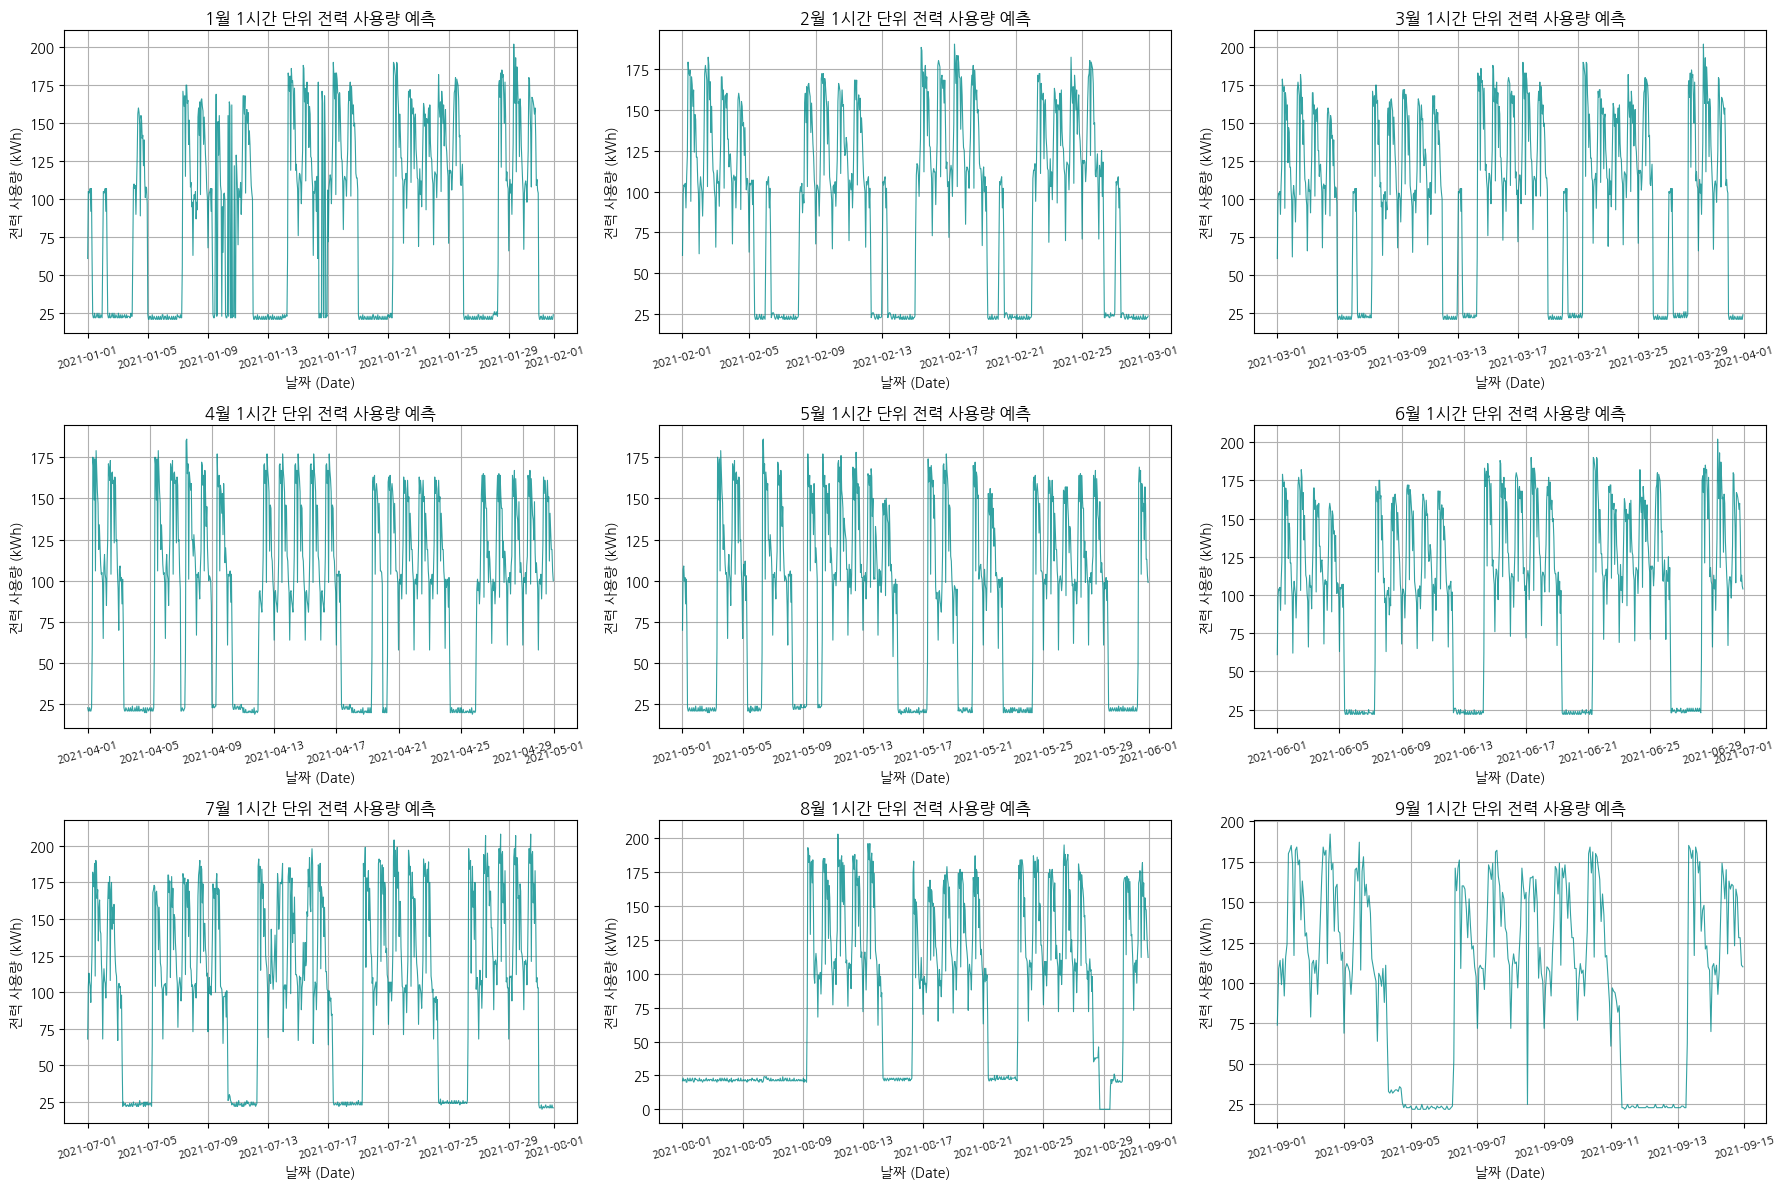


 [4] 1~9월 월별 평일 vs 주말 시간대별 전력 사용 패턴 비교


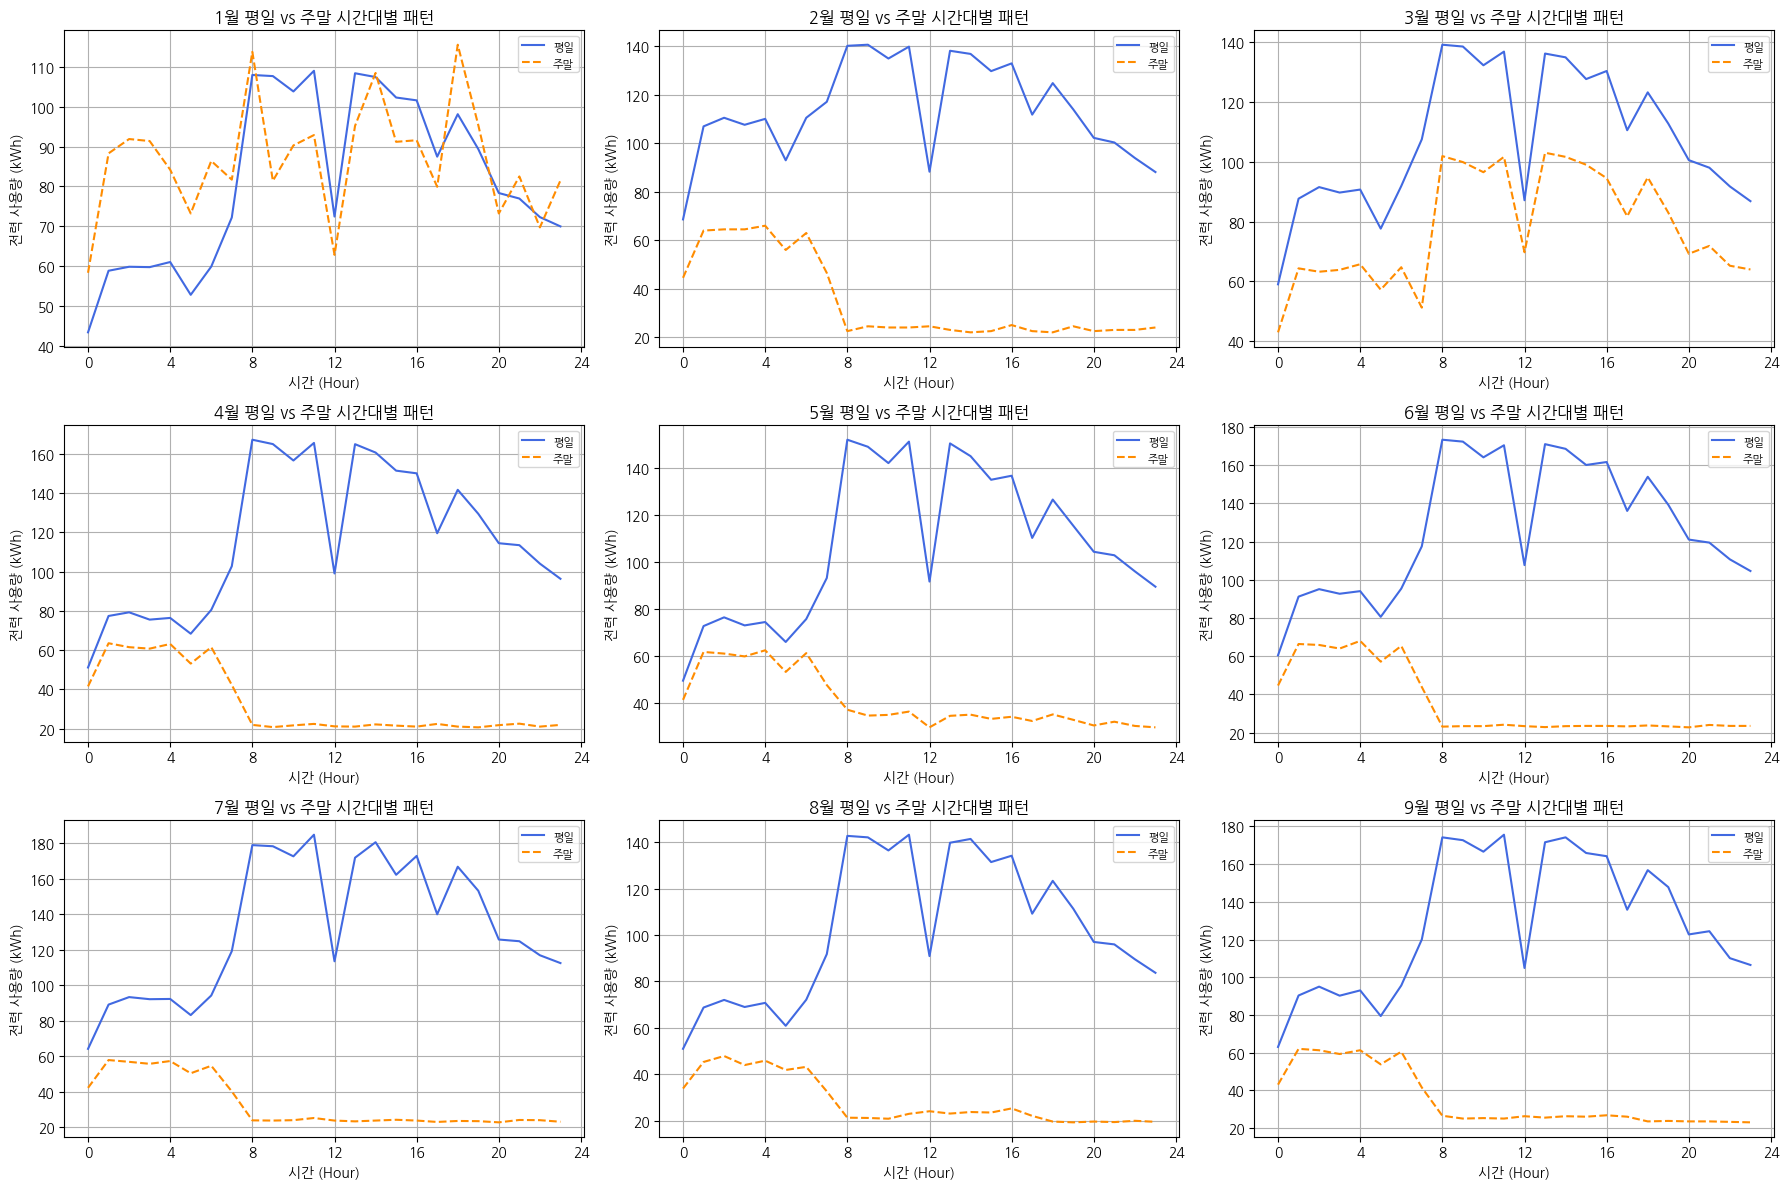


 [5] 평일 vs 주말 하루 평균 운영 지표 비교 (1~8월 기준)
 [평일 (Weekday) 하루 평균 예상 운영 지표]
  - 하루 총 전력 사용량: 2,677.08 kWh
  - 하루 전력 최대값: 168.93 kWh
  - 하루 전력 최소값: 51.64 kWh
  - 하루 총 생산량: 15,243.83
  - 하루 총 인건비: 34.99 * 시급 (원)
  - 하루 총 전기비: 442,781 원

 [주말 (Weekend) 하루 평균 예상 운영 지표]
  - 하루 총 전력 사용량: 1,124.79 kWh
  - 하루 전력 최대값: 90.91 kWh
  - 하루 전력 최소값: 23.04 kWh
  - 하루 총 생산량: 923.37
  - 하루 총 인건비: 4.40 * 시급 (원)
  - 하루 총 전기비: 172,466 원


In [15]:
import platform

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
else:
    plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

# 데이터 불러오기
file_path = "okm_augumented_2021_processed.xlsx"
df = pd.read_excel(file_path)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df = df.interpolate(method="linear").dropna()

# 1~8월: 종합 요약 · 월별 표용 (9월은 14일까지만 있어 제외)
df_1_8 = df[
    (df["datetime"].dt.month >= 1) & (df["datetime"].dt.month <= 8)
].copy()

# 1~9월: 그래프용
df_1_9 = df[
    (df["datetime"].dt.month >= 1) & (df["datetime"].dt.month <= 9)
].copy()

print("=" * 70)
print(" ⚡ [시나리오 D 기반] 1~8월 전력 사용량 및 운영 비용 종합 예측 리포트")
print("=" * 70)

# ==========================================
# [파트 1] 1~8월 종합 지표
# ==========================================
total_pred_power = df_1_8["평균"].sum()
max_power = df_1_8["전력 최대값"].max()
min_power = df_1_8["전력 최소값"].min()
total_production = df_1_8["생산량"].sum()

# 총 인건비 계수 = Σ(공장인원 × 인건비 배율)  → 시급을 곱하면 인건비
if "공장인원" in df_1_8.columns and "인건비" in df_1_8.columns:
    total_labor_factor = (df_1_8["공장인원"] * df_1_8["인건비"]).sum()
else:
    total_labor_factor = 0.0

# 총 전기요금 = Σ(전력 × 계절별 단가)
if "전기요금(계절)" in df_1_8.columns:
    total_electricity_cost = (
        df_1_8["평균"] * df_1_8["전기요금(계절)"]
    ).sum()
else:
    total_electricity_cost = total_pred_power * 150

print(f"\n[1] 1~8월 전체 종합 예측 요약 (9월 제외)")
print(f" - 총 전력 사용 예측량: {total_pred_power:,.2f} kWh")
print(f" - 전력 최대값: {max_power:,.2f} kWh")
print(f" - 전력 최소값: {min_power:,.2f} kWh")
print(f" - 총 생산량: {total_production:,.2f}")
print(f" - 총 인건비: {total_labor_factor:,.2f} * 시급 (원)")
print(f" - 총 전기비: {total_electricity_cost:,.0f} 원")

# ==========================================
# [파트 2] 월별 전력량 · 기상 요약 (1~8월)
# ==========================================
print("\n" + "=" * 70)
print(
    " [2] 월별 상세 예측 (1~8월) (전력량 및 기상 정보: 기온, 강수량, 풍속,"
    " 습도)"
)
print("=" * 70)

monthly_report = []
for m in range(1, 9):  # 1~8월
    m_df = df_1_8[df_1_8["datetime"].dt.month == m]
    if m_df.empty:
        continue

    m_power = m_df["평균"].sum()
    m_temp = m_df["기온"].mean()
    m_rain = m_df["강수량"].mean()
    m_wind = m_df["풍속"].mean()
    m_humidity = m_df["습도"].mean()

    monthly_report.append(
        {
            "월": f"{m}월",
            "예측 전력량(kWh)": f"{m_power:,.2f}",
            "평균 기온(℃)": f"{m_temp:.1f}",
            "평균 강수량(mm)": f"{m_rain:.1f}",
            "평균 풍속(m/s)": f"{m_wind:.1f}",
            "평균 습도(%)": f"{m_humidity:.1f}",
        }
    )

monthly_df = pd.DataFrame(monthly_report)
print(monthly_df.to_string(index=False))

# ==========================================
# [파트 3] 월별 1시간 단위 전력 사용량 추이 (1~9월, 3x3 그래프)
# ==========================================
print("\n" + "=" * 70)
print(" [3] 1~9월 월별 1시간 단위 전력 사용 예측량 상세 추이 시각화")
print("=" * 70)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, m in enumerate(range(1, 10)):
    m_data = df_1_9[df_1_9["datetime"].dt.month == m].copy()
    ax = axes[idx]

    if m_data.empty:
        ax.set_title(f"{m}월 (데이터 없음)")
        continue

    # 1시간 단위 원본 시계열
    ax.plot(
        m_data["datetime"],
        m_data["평균"],
        color="darkcyan",
        linewidth=0.8,
        alpha=0.8,
    )
    ax.set_title(f"{m}월 1시간 단위 전력 사용량 예측")
    ax.set_xlabel("날짜 (Date)")
    ax.set_ylabel("전력 사용량 (kWh)")
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation=15, fontsize=8)

plt.tight_layout()
plt.show()

# ==========================================
# [파트 4] 월별 평일 vs 주말 시간대별 평균 전력 패턴 (1~9월)
# ==========================================
print("\n" + "=" * 70)
print(" [4] 1~9월 월별 평일 vs 주말 시간대별 전력 사용 패턴 비교")
print("=" * 70)

df_1_9["weekday"] = df_1_9["datetime"].dt.weekday

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, m in enumerate(range(1, 10)):
    m_data = df_1_9[df_1_9["datetime"].dt.month == m].copy()
    ax = axes[idx]

    if m_data.empty:
        ax.set_title(f"{m}월 (데이터 없음)")
        continue

    # 시각을 소수 시간으로 변환 (예: 13시 30분 → 13.5)
    m_data["hour_min"] = (
        m_data["datetime"].dt.hour + m_data["datetime"].dt.minute / 60.0
    )

    # 평일 / 주말 시간대별 평균
    wk_pattern = (
        m_data[m_data["weekday"] < 5].groupby("hour_min")["평균"].mean().sort_index()
    )
    we_pattern = (
        m_data[m_data["weekday"] >= 5].groupby("hour_min")["평균"].mean().sort_index()
    )

    # 데이터가 있을 때만 그림
    if not wk_pattern.empty:
        ax.plot(
            wk_pattern.index,
            wk_pattern.values,
            label="평일",
            color="royalblue",
            linewidth=1.5,
        )
    if not we_pattern.empty:
        ax.plot(
            we_pattern.index,
            we_pattern.values,
            label="주말",
            color="darkorange",
            linewidth=1.5,
            linestyle="--",
        )

    ax.set_title(f"{m}월 평일 vs 주말 시간대별 패턴")
    ax.set_xlabel("시간 (Hour)")
    ax.set_ylabel("전력 사용량 (kWh)")
    ax.set_xticks(range(0, 25, 4))
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()
# ==========================================
# [파트 5] 평일 vs 주말 하루 평균 운영 지표 (1~8월)
# ==========================================
print("\n" + "=" * 70)
print(" [5] 평일 vs 주말 하루 평균 운영 지표 비교 (1~8월 기준)")
print("=" * 70)

df_1_8["weekday"] = df_1_8["datetime"].dt.weekday
df_1_8["date"] = df_1_8["datetime"].dt.date


def get_daily_average_metrics(subset):
    if subset.empty:
        return 0, 0, 0, 0, 0, 0

    # 날짜별 하루 합계 · 최대 · 최소
    daily_summary = []
    for date_val, group in subset.groupby("date"):
        d_power_sum = group["평균"].sum()
        d_max = (
            group["전력 최대값"].max()
            if "전력 최대값" in group.columns
            else group["평균"].max()
        )
        d_min = (
            group["전력 최소값"].min()
            if "전력 최소값" in group.columns
            else group["평균"].min()
        )
        d_prod = group["생산량"].sum() if "생산량" in group.columns else 0
        d_labor = (
            (group["공장인원"] * group["인건비"]).sum()
            if ("공장인원" in group.columns and "인건비" in group.columns)
            else 0.0
        )
        d_elec = (
            (group["평균"] * group["전기요금(계절)"]).sum()
            if "전기요금(계절)" in group.columns
            else d_power_sum * 150
        )

        daily_summary.append({
            "power_sum": d_power_sum,
            "max": d_max,
            "min": d_min,
            "production": d_prod,
            "labor": d_labor,
            "elec": d_elec,
        })

    daily_df = pd.DataFrame(daily_summary)

    # 하루 평균값 반환
    return (
        daily_df["power_sum"].mean(),
        daily_df["max"].mean(),
        daily_df["min"].mean(),
        daily_df["production"].mean(),
        daily_df["labor"].mean(),
        daily_df["elec"].mean(),
    )


wk_daily = df_1_8[df_1_8["weekday"] < 5]
we_daily = df_1_8[df_1_8["weekday"] >= 5]

wk_metrics = get_daily_average_metrics(wk_daily)
we_metrics = get_daily_average_metrics(we_daily)

print(
    f" [평일 (Weekday) 하루 평균 예상 운영 지표]\n"
    f"  - 하루 총 전력 사용량: {wk_metrics[0]:,.2f} kWh\n"
    f"  - 하루 전력 최대값: {wk_metrics[1]:,.2f} kWh\n"
    f"  - 하루 전력 최소값: {wk_metrics[2]:,.2f} kWh\n"
    f"  - 하루 총 생산량: {wk_metrics[3]:,.2f}\n"
    f"  - 하루 총 인건비: {wk_metrics[4]:,.2f} * 시급 (원)\n"
    f"  - 하루 총 전기비: {wk_metrics[5]:,.0f} 원\n"
)

print(
    f" [주말 (Weekend) 하루 평균 예상 운영 지표]\n"
    f"  - 하루 총 전력 사용량: {we_metrics[0]:,.2f} kWh\n"
    f"  - 하루 전력 최대값: {we_metrics[1]:,.2f} kWh\n"
    f"  - 하루 전력 최소값: {we_metrics[2]:,.2f} kWh\n"
    f"  - 하루 총 생산량: {we_metrics[3]:,.2f}\n"
    f"  - 하루 총 인건비: {we_metrics[4]:,.2f} * 시급 (원)\n"
    f"  - 하루 총 전기비: {we_metrics[5]:,.0f} 원"
)